In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
# ===== 薄样品吸收验证 (W): config_dict 模板与厚度定义 =====

W_DENSITY = 19.35  # g/cm^3

thicknesses_um = [1, 2, 5]
thicknesses_m = [t * 1e-6 for t in thicknesses_um]

grid_dir = rave_sim_dir / "grid"
grid_paths = [
    str(grid_dir / f"thin_w_plate_{t}um_200um.npy")
    for t in thicknesses_um
]

def make_config_with_sample(grid_path):
    return {
        "sim_params": {
            "is2d": 'true',
            "N": 16384 * 16384,
            "nx": 16384,
            "ny": 16384,
            "dx": 8.5e-8,
            "z_detector": 4.0,
            "detector_size": 0.85e-3,
            "detector_size_y": 0.85e-3,
            "detector_pixel_size_x": 2e-7,
            "detector_pixel_size_y": 2e-7,
            "chunk_size": 2*1024*1024*1024 // 16,
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9999, 10001],
            "x_range": [-1e-6, 1e-6],
            "y_range": [-1e-6, 1e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 1,
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 1.0,
                "pixel_size_x": 5e-8,
                "pixel_size_y": 5e-8,
                "pixel_size_z": 5e-8,
                "grid_path": grid_path,
                "materials": [["W", W_DENSITY]],
                "x_positions": [0],
                "y_positions": [0],
            },
        ],
    }

def make_empty_config():
    cfg = make_config_with_sample("")
    cfg["elements"] = []
    return cfg

print("Config template ready")
print(f"Thicknesses: {thicknesses_um} um")
for p in grid_paths:
    exists = "EXISTS" if Path(p).exists() else "MISSING"
    print(f"  {Path(p).name}: {exists}")

Config template ready
Thicknesses: [1, 2, 5] um
  thin_w_plate_1um_200um.npy: EXISTS
  thin_w_plate_2um_200um.npy: EXISTS
  thin_w_plate_5um_200um.npy: EXISTS


In [5]:
# ===== 空场参考：测量 I₀ =====

print("=" * 60)
print("Empty-field reference (no sample)")
print("=" * 60)

config_empty = make_empty_config()
sim_path_empty = multisim.setup_simulation(config_empty, Path("."), simulations_dir)
computed = config.load(Path(sim_path_empty / 'computed.yaml'))

for i in tqdm(range(config_empty["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path_empty}")

wavefronts_empty = util.load_wavefronts_filtered(sim_path_empty, x_range=(-30e-6, 30e-6))
wf_empty = np.sum([r[0] for r in wavefronts_empty], axis=0)
det_empty = wf_empty[0].astype(np.float64)
ny, nx = det_empty.shape
cy, cx = ny // 2, nx // 2
roi = 50
I0 = det_empty[cy-roi:cy+roi, cx-roi:cx+roi].mean()

print(f"Detector shape: {det_empty.shape}")
print(f"I₀ (center mean) = {I0:.6e}")

2026-07-05 10:59:16,821 INFO: Setting up simulation
2026-07-05 10:59:16,822 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m
2026-07-05 10:59:16,823 INFO: 2D Nyquist check: dz=4.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-07-05 10:59:16,853 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_105916827966


Empty-field reference (no sample)


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-07-05 10:59:17.022] [info] Detector 2D mode
[2026-07-05 10:59:17.022] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_105916827966/00000000
[2026-07-05 10:59:17.022] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-07-05 10:59:17.022] [info] GPU memory required for wavefield: 2048 MB
[2026-07-05 10:59:17.506] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-07-05 10:59:17.614] [info]   Number of optical elements: 0
[2026-07-05 10:59:17.614] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-07-05 10:59:17.614] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07 (effective)
[2026-07-05 10:59:17.614] [info]   current_z=4 (effective), dx=8.5e-08, dy=8.5e-08


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.63s/it]

[2026-07-05 10:59:18.429] [info] 2D Simulation finished in 1.406898653 seconds


Detector shape: (4250, 4250)
I₀ (center mean) = 2.533087e-15


In [6]:
# ===== W 薄板吸收仿真（厚度扫描）=====

center_intensities = []
all_detectors = []
all_sim_paths = []

for iz, (t_um, t_m, gpath) in enumerate(zip(thicknesses_um, thicknesses_m, grid_paths)):
    print(f"\n{'='*60}")
    print(f"[{iz+1}/{len(thicknesses_um)}] W plate: t = {t_um} um")
    print('='*60)

    config_dict = make_config_with_sample(gpath)
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    _ = config.load(Path(sim_path / 'computed.yaml'))

    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
    wf = np.sum([r[0] for r in wavefronts], axis=0)
    det = wf[0].astype(np.float64)

    I_center = det[cy-roi:cy+roi, cx-roi:cx+roi].mean()
    center_intensities.append(I_center)
    all_detectors.append(det)
    all_sim_paths.append(sim_path)

    print(f"  Center intensity: {I_center:.6e}")
    print(f"  Transmission I/I₀ = {I_center/I0:.6f}")

2026-07-05 10:59:18,995 INFO: Setting up simulation
2026-07-05 10:59:18,996 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m



[1/3] W plate: t = 1 um


2026-07-05 10:59:34,016 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-07-05 10:59:54,585 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_105934092270
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-07-05 11:00:04.148] [info] Detector 2D mode
[2026-07-05 11:00:04.150] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_105934092270/00000000
[2026-07-05 11:00:04.150] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-07-05 11:00:04.150] [info] GPU memory required for wavefield: 2048 MB
[2026-07-05 11:00:04.474] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-07-05 11:00:04.548] [info]   Number of optical elements: 1
[2026-07-05 11:00:10.406] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-07-05 11:00:10.406] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07 (effective)
[2026-07-05 11:00:10.406] [info]   current_z=4 (effective), dx=8.5e-08, dy=8.5e-08


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:16<00:00, 16.63s/it]

...

  Center intensity: 1.780118e-15
  Transmission I/I₀ = 0.702747

[3/3] W plate: t = 5 um


2026-07-05 11:03:09,924 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-07-05 11:04:51,946 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_110310260048
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-07-05 11:05:38.813] [info] Detector 2D mode
[2026-07-05 11:05:38.814] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260705_110310260048/00000000
[2026-07-05 11:05:38.814] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-07-05 11:05:38.814] [info] GPU memory required for wavefield: 2048 MB
[2026-07-05 11:05:39.287] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-07-05 11:05:39.373] [info]   Number of optical elements: 1
[2026-07-05 11:06:11.519] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-07-05 11:06:11.519] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07 (effective)
[2026-07-05 11:06:11.519] [info]   current_z=4 (effective), dx=8.5e-08, dy=8.5e-08
[2026-07-05 11:06:12.244] [info] 2D Simulation finished in 33.430354426 seconds


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:21<00:00, 81.10s/it]


  Center intensity: 1.038106e-15
  Transmission I/I₀ = 0.409818


In [7]:
# ===== Beer-Lambert 吸收定律定量验证 =====

transmission_meas = np.array(center_intensities) / I0

from nist_lookup.xraydb_plugin import xray_delta_beta

energy = 10000  # eV (仿真配置中心能量)
delta_W, beta_W, atlen_W = xray_delta_beta("W", 19.35, energy)
lam = 6.62607004e-34 * 299792458.0 / (energy * 1.602176634e-19)
mu_theory = 4 * math.pi * beta_W / lam
transmission_theory = np.exp(-mu_theory * np.array(thicknesses_m))

print("=" * 70)
print("Beer-Lambert Absorption Validation: W thin plates")
print(f"Energy: {energy} eV")
print(f"Wavelength: {lam:.4e} m")
print(f"beta_W = {beta_W:.4e}")
print(f"mu_theory = {mu_theory:.4e} m⁻¹  (={mu_theory/100:.2f} cm⁻¹)")
print("=" * 70)
print(f"{'t (um)':<10} {'I/I₀ (sim)':<15} {'I/I₀ (theory)':<15} {'ratio':<10}")
print("-" * 55)
for t, meas, theo in zip(thicknesses_um, transmission_meas, transmission_theory):
    print(f"{t:<10} {meas:<15.6f} {theo:<15.6f} {meas/theo:<10.4f}")
print("-" * 55)

mu_fitted = -np.log(transmission_meas) / np.array(thicknesses_m)
mu_mean = mu_fitted.mean()
mu_std = mu_fitted.std()
mu_err = abs(mu_mean - mu_theory) / mu_theory * 100
print(f"\nmu_fitted = {mu_mean:.4e} ± {mu_std:.4e} m⁻¹")
print(f"mu_theory = {mu_theory:.4e} m⁻¹")
print(f"Deviation: {mu_err:.2f}%")

if mu_err < 5:
    print("\n✅ 吸收验证通过: 仿真与 Beer-Lambert 理论偏差 < 5%")
else:
    print(f"\n⚠️ 吸收验证: 偏差 {mu_err:.2f}% (> 5%)")

Beer-Lambert Absorption Validation: W thin plates
Energy: 10000 eV
Wavelength: 1.2398e-10 m
beta_W = 1.7839e-06
mu_theory = 1.8080e+05 m⁻¹  (=1808.03 cm⁻¹)
t (um)     I/I₀ (sim)      I/I₀ (theory)   ratio     
-------------------------------------------------------
1          0.837231        0.834599        1.0032    
2          0.702747        0.696556        1.0089    
5          0.409818        0.404940        1.0120    
-------------------------------------------------------

mu_fitted = 1.7748e+05 ± 8.3740e+02 m⁻¹
mu_theory = 1.8080e+05 m⁻¹
Deviation: 1.84%

✅ 吸收验证通过: 仿真与 Beer-Lambert 理论偏差 < 5%


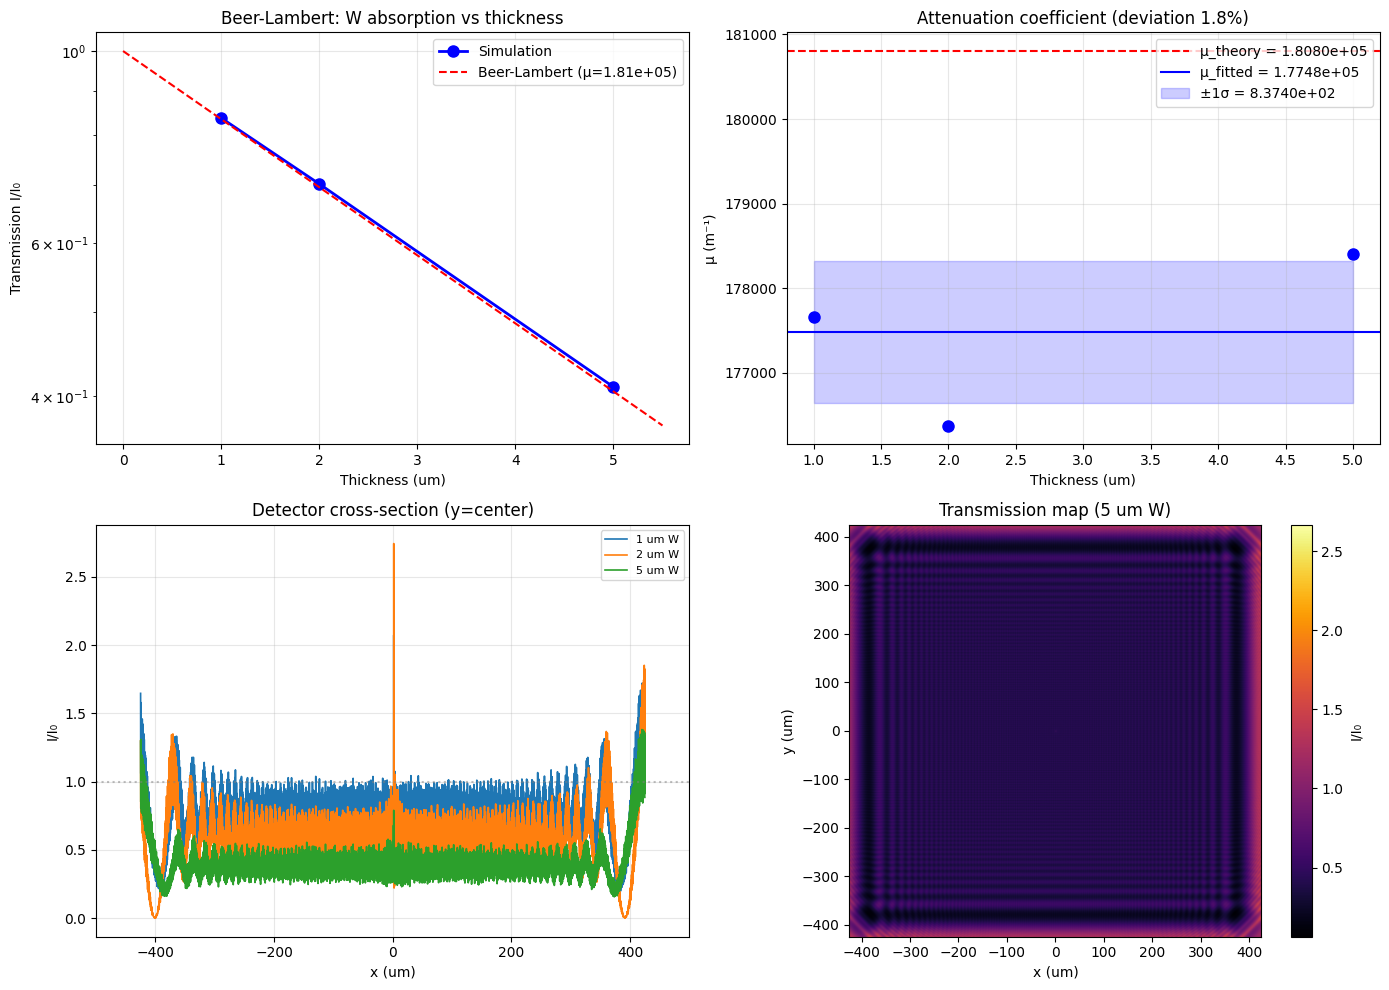

Saved thin_w_absorption_validation.png


In [8]:
# ===== 可视化 =====

det_pixel_um = 0.2  # 200 nm -> um

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 透射率 vs 厚度 (半对数)
ax = axes[0, 0]
z_fit = np.linspace(0, max(thicknesses_um)*1.1, 100)
ax.semilogy(thicknesses_um, transmission_meas, 'bo-', lw=2, markersize=8, label='Simulation')
ax.semilogy(z_fit, np.exp(-mu_theory * z_fit*1e-6), 'r--', lw=1.5, label=f'Beer-Lambert (μ={mu_theory:.2e})')
ax.set_xlabel('Thickness (um)')
ax.set_ylabel('Transmission I/I₀')
ax.set_title('Beer-Lambert: W absorption vs thickness')
ax.legend()
ax.grid(alpha=0.3)

# (b) 拟合衰减系数
ax = axes[0, 1]
ax.axhline(mu_theory, color='r', ls='--', lw=1.5, label=f'μ_theory = {mu_theory:.4e}')
ax.axhline(mu_mean, color='b', ls='-', lw=1.5, label=f'μ_fitted = {mu_mean:.4e}')
ax.fill_between(thicknesses_um, mu_mean - mu_std, mu_mean + mu_std,
                alpha=0.2, color='b', label=f'±1σ = {mu_std:.4e}')
ax.plot(thicknesses_um, mu_fitted, 'bo', ms=8)
ax.set_xlabel('Thickness (um)')
ax.set_ylabel('μ (m⁻¹)')
ax.set_title(f'Attenuation coefficient (deviation {mu_err:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)

# (c) 各厚度探测器中心剖面线
ax = axes[1, 0]
for iz, (t, det) in enumerate(zip(thicknesses_um, all_detectors)):
    line = det[cy, :] / I0
    x_um = (np.arange(len(line)) - nx//2) * det_pixel_um
    ax.plot(x_um, line, lw=1.2, label=f'{t} um W')
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('x (um)')
ax.set_ylabel('I/I₀')
ax.set_title('Detector cross-section (y=center)')
ax.legend(fontsize=8)
ax.set_xlim(-500, 500)
ax.grid(alpha=0.3)

# (d) 最厚样品的透射率图
ax = axes[1, 1]
det_ratio = all_detectors[-1] / det_empty
im = ax.imshow(det_ratio, cmap='inferno',
               extent=[-nx*det_pixel_um/2, nx*det_pixel_um/2,
                       -ny*det_pixel_um/2, ny*det_pixel_um/2])
plt.colorbar(im, ax=ax, label='I/I₀')
ax.set_title(f'Transmission map ({thicknesses_um[-1]} um W)')
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')

plt.tight_layout()
plt.savefig('thin_w_absorption_validation.png', dpi=150)
plt.show()
print('Saved thin_w_absorption_validation.png')